# Here we are going ot build a basic chat bot with langgaph ( graph api)

In [2]:
## Basic Components of Langgraph
# 1. Edge
# 2. Node
# 3. State { Every node has a state and this state can be used to trigger the next node in the graph }
# The entire graph is known as a state graph.


#There are two ways of solving any flows in langgraph
# 1. Graph API
# 2. Functioal API

# We will be creating som graph and this graph will

import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import Annotated # Add context-specific metadata to a type.
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # These are the reducers which will help us to add messages to the state of the node.
# each and every message is appended in the state for each conversation and this is how we can keep the track of the conversation and also we can use this for the summarization of the conversation.



In [4]:
class State(TypedDict):
    # Messages have the type "list". Thel 'add _messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them),
    messages: Annotated[list, add_messages] # It is not going to replace but append the list.

graph_builder = StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10ada0d70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ada1a90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Defining the node functionality
def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

#adding nodes
graph_builder.add_node("llmchatbot", chatbot)
#adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

#Compile the graph
graph = graph_builder.compile()

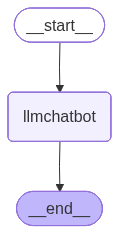

In [9]:
graph

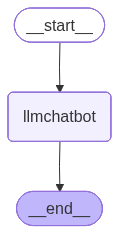

In [10]:
# Visaulaization the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({"messages": "hi"})

In [12]:
response["messages"][-1].content

'How can I assist you today?'

In [13]:
for event in graph.stream({"messages":"Hi How are you?"}):
    print (event)

{'llmchatbot': {'messages': [AIMessage(content="I'm just a language model, I don't have emotions or feelings like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 40, 'total_tokens': 85, 'completion_time': 0.281716614, 'completion_tokens_details': None, 'prompt_time': 0.001970619, 'prompt_tokens_details': None, 'queue_time': 0.049396516, 'total_time': 0.283687233}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7000-22f8-7f40-86be-977b2c596cc7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 45, 'total_tokens': 85})]}}


# Chatbot with tool

In [53]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results = 2)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'page 4',
   'content': 'Paris is the **capital of [France](http://www.parisdigest.com/famous_places_in_france.htm)**, the largest country of [Europe](http://www.parisdigest.com/famous_places_in_europe) with 550 000 km2 (65 millions inhabitants). Founded more than 2000 years ago, Paris is a modern and vibrant city with significant [commercial](http://www.parisdigest.com/menus/shopping.htm), [cultural](http://www.parisdigest.com/goingout/showtickets.htm), academic, scientific, administrative, [business](http://www.parisdigest.com/menus/business.htm) activity. See details of [Paris history](http://www.parisdigest.com/history/paris_history.htm). Paris is a world capital city of [shopping](http://www.parisdigest.com/menus/shopping.htm) and [fashion](http://www.parisdigest.com/menus/fashion.htm), with Ch

In [54]:
## Custom function  (Example of using doc string )
def multiply(a:int, b:int) ->int:
    """Multiply a and b

        ARGS:
        a (int): first integer
        b (int): second integer 

        Returns:
        int: output int
    """
    return a*b

In [55]:
tools = [tool, multiply]

llm_with_tools = llm.bind_tools(tools)

In [56]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10ada0d70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ada1a90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, a

In [57]:
## Creating the entire state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"message":llm_with_tools.invoke(state["messages"])}

# Node Definition
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


#Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)

graph = builder.compile()


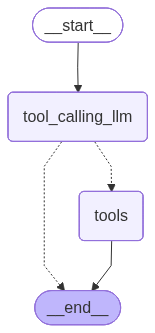

In [58]:
graph

In [63]:
response = graph.invoke({"messages":"What is 5 multiplied by 4 "})

for m in response['messages']:
    m.pretty_print()

# Somehow my tools are not working in here.

================================ Human Message =================================

What is 5 multiplied by 4 


In [ ]:
## There are something called as ReACT agent
# The actual agent behavious starts from here.